In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multicomp import MultiComparison
import scipy.stats as stats
import os
from scipy import stats
from matplotlib.offsetbox import AnchoredText
import matplotlib.patches as mpl_patches
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
from matplotlib import gridspec

In [2]:
df = pd.read_table('Fig1c_test.txt')
df.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,Mg,PC1,PC2,S470fs,top_peak,splice,N715A,Chr5_21390834,Chr5_21392702,Chr5_282011
0,88,CYR,France,47.4000,0.683333,CS76790,leaf,France_leaf,4513.790113,11.829166,...,38,-0.024919,0.024124,0,0,0,1,0.0,0.0,1.0
1,108,LDV-18,France,48.5167,-4.066670,CS77013,leaf,France_leaf,4444.244161,11.100000,...,31,-0.017065,0.018734,0,0,0,1,0.0,0.0,1.0
2,139,LDV-46,France,48.5167,-4.066670,CS77014,leaf,France_leaf,4548.751871,11.100000,...,31,-0.018403,0.018840,0,0,0,1,0.0,0.0,1.0
3,159,MAR2-3,France,47.3500,3.933330,CS77070,leaf,France_leaf,4808.545837,9.325000,...,29,-0.029610,0.022555,0,0,0,1,0.0,0.0,1.0
4,350,TOU-A1-88,France,46.6667,4.116670,CS77382,leaf,France_leaf,5189.422620,10.720833,...,36,-0.029266,0.026182,0,0,0,1,0.0,0.0,1.0


alt: 32
ref: 645
[0, 1]


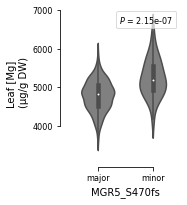

In [7]:
boxprops = {'edgecolor': 'black', 'linewidth': 0.5, 'facecolor': 'grey'}
lineprops = {'color': 'k', 'linewidth': 0.5}
boxplot_kwargs = dict({'boxprops': boxprops, 'medianprops': lineprops,
                       'whiskerprops': lineprops, 'capprops': lineprops,
                       'width': 0.6})

alt=df[df['S470fs'] == 1]
ref=df[df['S470fs'] == 0]
print('alt: ' + str(alt.shape[0]) + '\nref: ' + str(ref.shape[0]))

Order=[]
if alt.shape[0] > ref.shape[0]:
    Order=[1,0]
elif alt.shape[0] < ref.shape[0]:
    Order=[0,1]
print(Order)

@ticker.FuncFormatter
def major_formatter(x, pos):
    y = x /1000000
    return "%.0f" % y
cm = 1/2.54
plt.figure(figsize=(5*cm,7*cm))
ax=sns.violinplot(x='S470fs', 
            y='Mg25',
            color='grey',
            data=df,
            order=Order,
            linewidth=1.5,
            fliersize=0,
            **boxplot_kwargs)
# r,p = mannwhitneyu(leaf[leaf['top_peak'] == 'alt'],leaf[leaf['top_peak'] == 'ref'])
r,p = mannwhitneyu(alt['Mg25'],ref['Mg25'])
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 2
labels=[]
labels.append(r"$P$ = {:.2e}".format(p))
plt.legend(handles, labels, loc='best', fontsize=8, 
      fancybox=True, framealpha=0.7, 
      handlelength=0, handletextpad=0)
ax.set_xlabel('MGR5_S470fs',fontsize=10)
ax.set_xticklabels(['major', 'minor'])
plt.ylabel('Leaf [Mg] \n(µg/g DW)',fontsize=10)

sns.despine(trim=True,offset=10)
plt.tick_params(labelsize=8)
# plt.savefig("chr5_282011_vs_leafMg_20230926.png", format="png",bbox_inches="tight",facecolor='w',dpi=150)
# plt.savefig("chr5_282011_vs_leafMg_20230926.pdf", format="pdf",bbox_inches="tight",facecolor='w')